### NCF & Stacks

In [1]:
# Import necessary dependencies
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('..')
from src.plot import plot_ncf_section

from src.utils import parse_ncf_filename, fk_velocity_filter
from src.ani import bandpass_filter_tukey 

#### 1. Path setup

In [2]:
# Define NCF paths
ncf_raw     = '../data/ncf_raw/20210927_000000_cc_080.npy'
ncf_daily   = '../data/ncf_stacks/daily/20210927_cc_080_daily.npy'
ncf_weekly  = '../data/ncf_stacks/7d/20210927_cc_080_7d.npy'

base = '20210927_cc_080_7d'
filename = '20210927_cc_080_7d.npy'

In [3]:
# Extract parameters
_, vs, window = parse_ncf_filename(ncf_daily)

In [4]:
# Load NCF data and stacks
ncf_raw_ = np.load(ncf_raw)
ncf_daily_ = np.load(ncf_daily)
ncf_weekly_ = np.load(ncf_weekly)
# ncf_biweekly_ = np.load(ncf_biweekly)

In [5]:
# Define parameters
dt = 0.004      # sampling rate in sec (or 250 Hz)
fs = 250        # sampling frequency (Hz)

# Max lag and sample rate
max_lag = 2.0   # seconds 
npts_lag = int(max_lag * fs)

# Cable configuration
first_chan = 399
last_chan = 748
dx = 8.16       # `chann_len` in meters
channels = np.arange(first_chan, last_chan + 1)

#### 1. Raw NCF

In [6]:
# Extract metadata
n_rec, n_lags = ncf_raw_.shape

# Lag axis spans from –max_lag ... +max_lag
lag_axis = np.linspace(-max_lag, +max_lag, n_lags)

if len(channels) != n_rec:
    channels = np.arange(n_rec)

distance_axis = (channels - channels[0]) * dx

In [7]:
# Extract ncf data
print(f'Receiver channels: {n_rec}')
print(f'Lag dimension: {n_lags} samples → {2 * max_lag:.3f} s total window')
print(f'Processed sampling rate: {fs:.1f} Hz → dt_proc = {dt:.4f} s')
print(f'Lag axis (first/last): {lag_axis[0]:.3f} s, {lag_axis[-1]:.3f} s')
print('NCF data shape:', ncf_raw_.shape)

Receiver channels: 350
Lag dimension: 1001 samples → 4.000 s total window
Processed sampling rate: 250.0 Hz → dt_proc = 0.0040 s
Lag axis (first/last): -2.000 s, 2.000 s
NCF data shape: (350, 1001)


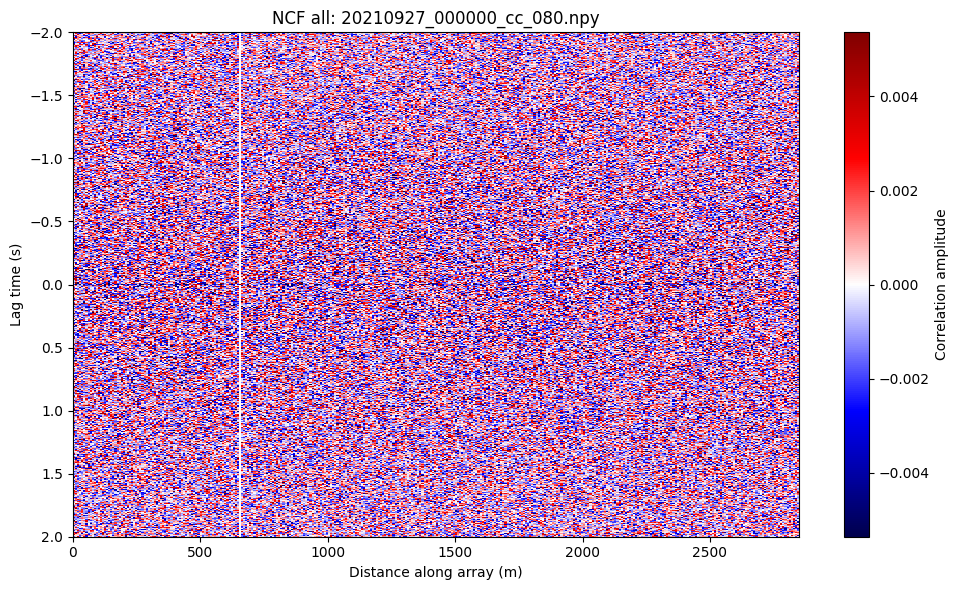

In [8]:
# Compute clipping value to avoid extreme outliers in the colormap
pclip = 99
ncf_clip = np.percentile(np.abs(ncf_raw_), pclip)
plot_ncf_section(ncf_raw_, lag_axis, distance_axis, mode="all", clip=ncf_clip, filename=ncf_raw)
# plot_ncf_section(ncf_raw_, lag_axis, distance_axis, mode="causal", clip=ncf_clip, filename=ncf_raw)
# plot_ncf_section(ncf_raw_, lag_axis, distance_axis, mode="acasual", clip=ncf_clip, filename=ncf_raw)

#### 2. Daily Stacked NCF

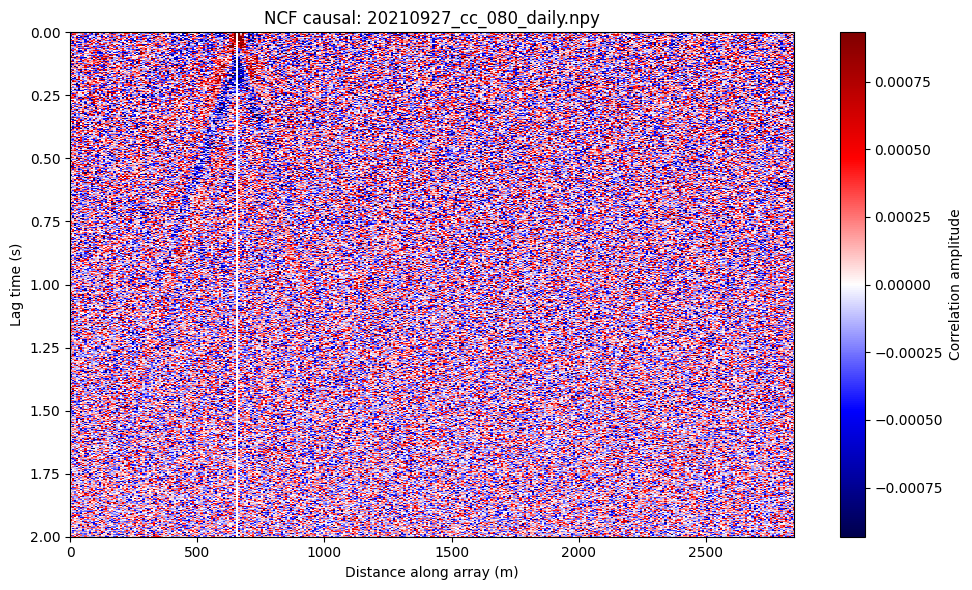

In [9]:
ncf_daily_clip = np.percentile(np.abs(ncf_daily_), 99)
plot_ncf_section(ncf_daily_, lag_axis, distance_axis, mode="causal", clip=ncf_daily_clip, filename=ncf_daily)

#### 3. Weekly Stacked NCF

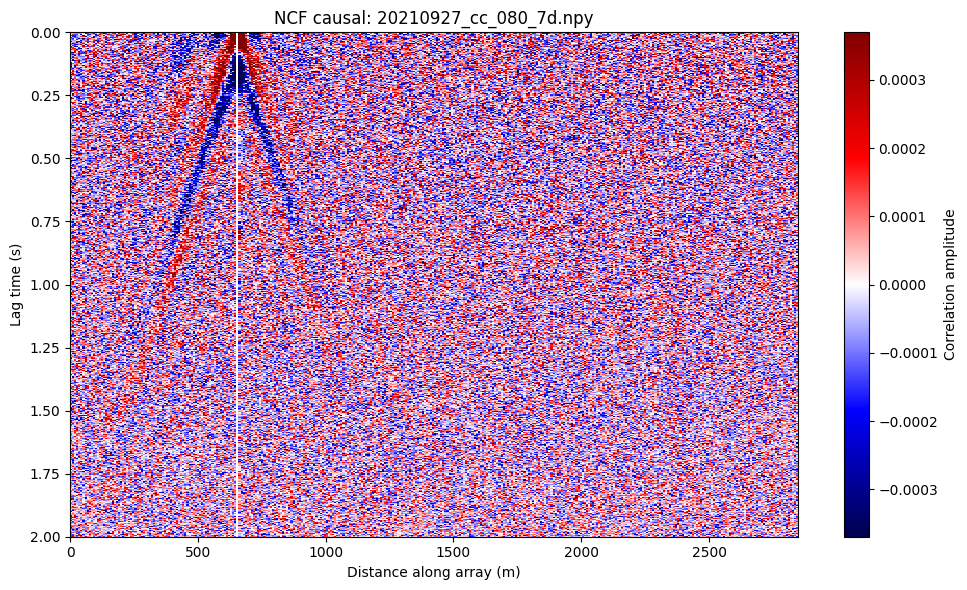

In [10]:
ncf_weekly_clip = np.percentile(np.abs(ncf_weekly_), 99)
plot_ncf_section(ncf_weekly_, lag_axis, distance_axis, mode="causal", clip=ncf_weekly_clip, filename=ncf_weekly)

#### 4. Butterworth Bandpass (Time Domain)

- Used for QC / inspection and deciding usable frequency band

- Not ideal as the primary conditioning for dispersion

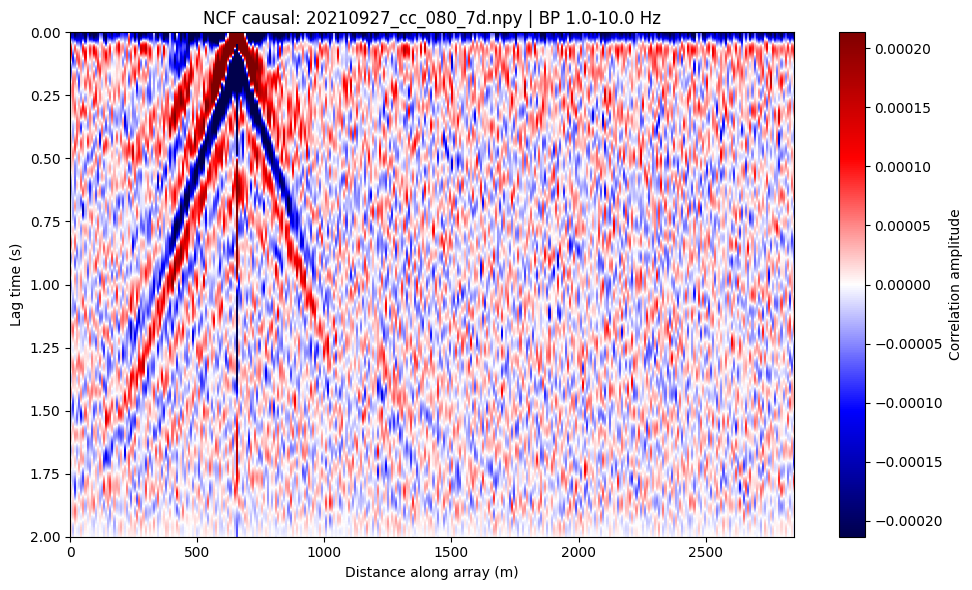

In [11]:
# Bandpass range
f1, f2 = 1.0, 10.0   # Hz
ncf_weekly_bp = bandpass_filter_tukey(
    ncf_weekly_,
    fs=fs,
    f1=f1,
    f2=f2,
    alpha=0.05,
    order=4,
    )

ncf_weekly_bp_clip = np.percentile(np.abs(ncf_weekly_bp), 99)
plot_ncf_section(ncf_weekly_bp, lag_axis, distance_axis, mode="causal", clip=ncf_weekly_bp_clip, filename=f"{ncf_weekly} | BP {f1}-{f2} Hz")

#### 5. f-k Filter

- Removing incoherent ambient noise

- Denoising NCFs before dispersion

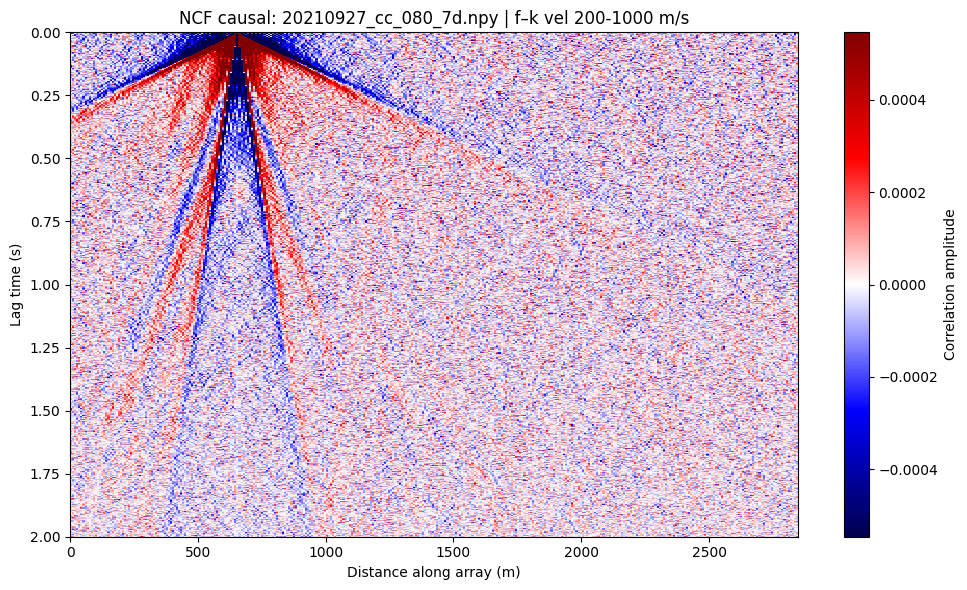

In [12]:
# f-k range
vmin = 200
vmax = 1000

ncf_weekly_fk = fk_velocity_filter(
    ncf_weekly_,
    dt=dt,
    dx=dx,
    vmin=150.0,
    vmax=2000.0,
    taper_frac=0.10,  
)

ncf_weekly_fk_clip = np.percentile(np.abs(ncf_weekly_fk), 99)
plot_ncf_section(ncf_weekly_fk, lag_axis, distance_axis, mode="causal", clip=ncf_weekly_fk_clip, title=f"{filename} | f–k vel {vmin}-{vmax} m/s")

#### 6. Trimmed NCF

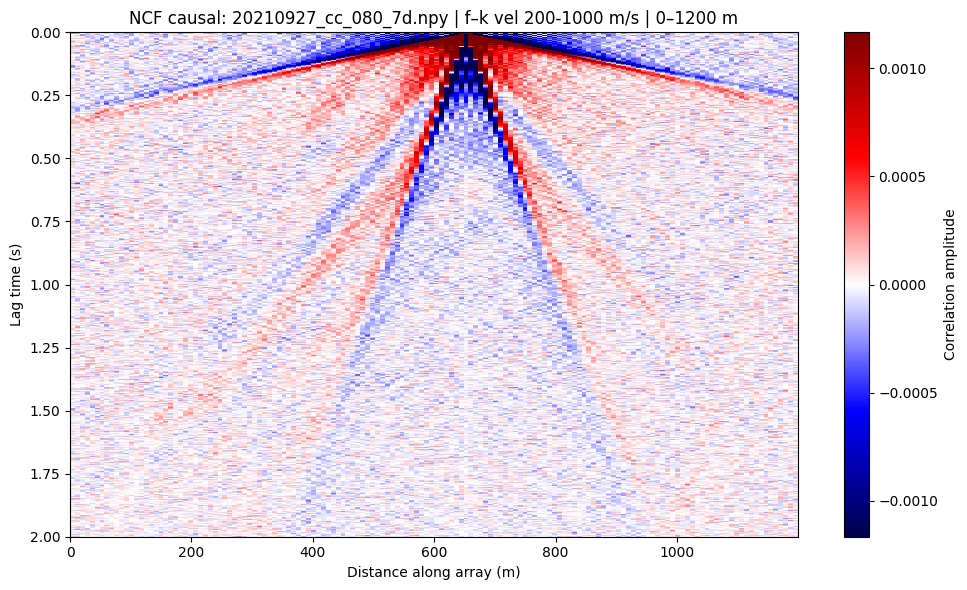

In [13]:
# Limit distance 
dmax = 1200.0  # meters
mask = distance_axis <= dmax

ncf_weekly_fk_lim = ncf_weekly_fk[mask, :]
distance_axis_lim = distance_axis[mask]

# Recompute clip on the limited aperture (important)
ncf_weekly_fk_lim_clip = np.percentile(
    np.abs(ncf_weekly_fk_lim), 99
)

plot_ncf_section(
    ncf_weekly_fk_lim,
    lag_axis,
    distance_axis_lim,
    mode="causal",
    clip=ncf_weekly_fk_lim_clip,
    title=f"{filename} | f–k vel {vmin}-{vmax} m/s | 0–{int(dmax)} m",
)

#### 7. Timelapse per one receiver

In [14]:
### TODO